In [ ]:
import pandas as pd                        # pandas handles tables (like Excel in Python)
import numpy as np                         # numpy handles math and numbers
import matplotlib.pyplot as plt            # matplotlib draws charts
import seaborn as sns                      # seaborn makes prettier charts on top of matplotlib
from scipy import stats                    # scipy gives us statistical tests like ANOVA
import statsmodels.api as sm               # statsmodels gives us regression models
from statsmodels.formula.api import ols, logit,probit    # ols = Ordinary Least Squares (type of regression)


print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/WA_Marketing-Campaign.csv')
print("File loaded successfully!")
#reading file

File loaded successfully!


In [ ]:
# Always check the first 5 rows after loading
print(df.head())
print("Rows    :", df.shape[0])
print("Columns :", df.shape[1])
print("Column names:", list(df.columns))

   MarketID MarketSize  LocationID  AgeOfStore  Promotion  week  \
0         1     Medium           1           4          3     1   
1         1     Medium           1           4          3     2   
2         1     Medium           1           4          3     3   
3         1     Medium           1           4          3     4   
4         1     Medium           2           5          2     1   

   SalesInThousands  
0             33.73  
1             35.67  
2             29.03  
3             39.25  
4             27.81  
Rows    : 548
Columns : 7
Column names: ['MarketID', 'MarketSize', 'LocationID', 'AgeOfStore', 'Promotion', 'week', 'SalesInThousands']


In [ ]:
# Basic info: column names, types, non-null counts
print(df.info())
print("\n\n")

# Summary statistics for every numeric column
print(round(df.describe(),4))
print("\n\n")

# Count missing values per column
print("\nMissing values:")
print(df.isnull().sum())
print("\n\n")

# See all column names clearly
print("\nColumns:", df.columns.tolist())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 548 entries, 0 to 547
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   MarketID          548 non-null    int64  
 1   MarketSize        548 non-null    object 
 2   LocationID        548 non-null    int64  
 3   AgeOfStore        548 non-null    int64  
 4   Promotion         548 non-null    int64  
 5   week              548 non-null    int64  
 6   SalesInThousands  548 non-null    float64
dtypes: float64(1), int64(5), object(1)
memory usage: 30.1+ KB
None



       MarketID  LocationID  AgeOfStore  Promotion      week  SalesInThousands
count  548.0000    548.0000    548.0000   548.0000  548.0000          548.0000
mean     5.7153    479.6569      8.5036     2.0292    2.5000           53.4662
std      2.8770    287.9737      6.6383     0.8107    1.1191           16.7552
min      1.0000      1.0000      1.0000     1.0000    1.0000           17.3400
25%    

/tmp/ipykernel_10038/1609183842.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=std_values.index, y=std_values.values, palette="Blues_d")
/tmp/ipykernel_10038/1609183842.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cv_percent.index, y=cv_percent.values, palette="Greens_d")


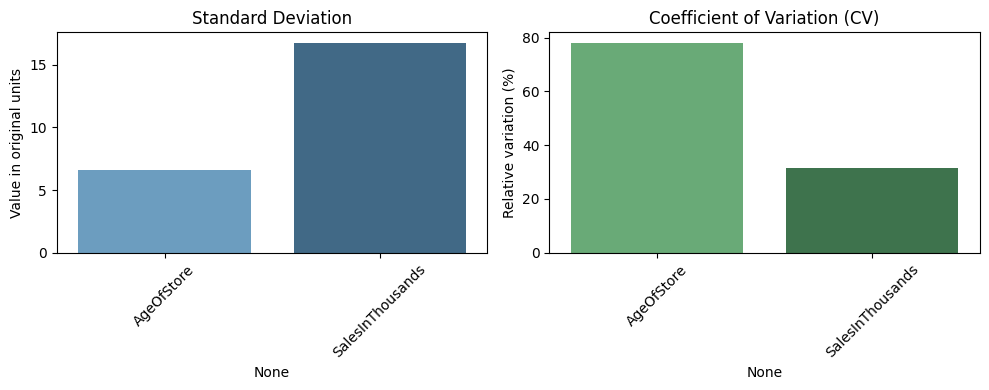

In [ ]:

# Columns to plot
cols_to_plot = ['AgeOfStore', 'SalesInThousands']

# Calculate statistics
std_values = df[cols_to_plot].std()
cv_percent = (std_values / df[cols_to_plot].mean()) * 100  # CV in %

# Plotting
plt.figure(figsize=(10,4))

# Standard Deviation
plt.subplot(1,2,1)
sns.barplot(x=std_values.index, y=std_values.values, palette="Blues_d")
plt.title("Standard Deviation")
plt.ylabel("Value in original units")
plt.xticks(rotation=45)

# Coefficient of Variation
plt.subplot(1,2,2)
sns.barplot(x=cv_percent.index, y=cv_percent.values, palette="Greens_d")
plt.title("Coefficient of Variation (CV)")
plt.ylabel("Relative variation (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

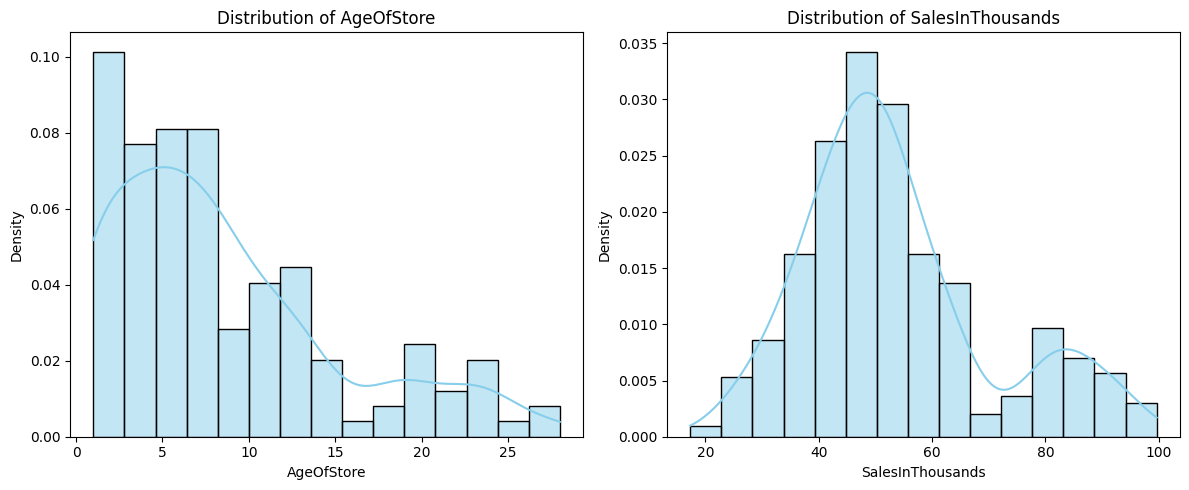

In [ ]:
# Create a figure (overall canvas) with width=12 and height=5
plt.figure(figsize=(12,5))

# Loop through the columns you want to plot
# enumerate gives:
# i = position (1, 2, ...)
# col = column name ('AgeOfStore', 'SalesInThousands')
for i, col in enumerate(cols_to_plot, 1):

    # Create a subplot grid: 1 row, 2 columns, position = i
    # So first plot goes left, second goes right
    plt.subplot(1, 2, i)

    # Plot histogram + KDE (smooth curve) for the column
    sns.histplot(
        df[col],            # data from the column
        kde=True,           # adds smooth density curve
        stat="density",     # shows probability density (not raw counts)
        color="skyblue",    # bar color
        bins=15             # number of bars (bins)
    )

    # Set title of each subplot
    plt.title(f"Distribution of {col}")

    # Label x-axis with column name
    plt.xlabel(col)

    # Label y-axis as density (since we used stat="density")
    plt.ylabel("Density")

# Adjust spacing so plots don’t overlap
plt.tight_layout()

# Display the final figure
plt.show()

In [ ]:
print("Records per Promotion:")
print(df['Promotion'].value_counts().sort_index())   # df['Promotion'] selects just that column
                                                     # .value_counts() counts how many rows each unique value has
                                                     # .sort_index() sorts by promotion number (1, 2, 3)

print("\nRecords per Market Size:")
print(df['MarketSize'].value_counts())   # same logic for MarketSize column
                                         # tells you how many rows belong to Small, Medium, Large




Records per Promotion:
Promotion
1    172
2    188
3    188
Name: count, dtype: int64

Records per Market Size:
MarketSize
Medium    320
Large     168
Small      60
Name: count, dtype: int64


In [ ]:

print("Average Sales by Promotion:")
print(df.groupby('Promotion')['SalesInThousands'].mean().round(2))
# .groupby('Promotion') splits the table into 3 groups (one per promotion)
# ['SalesInThousands'] selects the sales column within each group
# .mean() calculates the average sales for each group
# .round(2) rounds to 2 decimal places

print("\nAverage Sales by Market Size:")
print(df.groupby('MarketSize')['SalesInThousands'].mean().round(2))
# same logic -- splits by market size and computes average sales

print("\nAverage Sales by Week:")
print(df.groupby('week')['SalesInThousands'].mean().round(2))
# same logic -- splits by week number (1 to 4) and computes average sales

print("\nAverage Sales by AgeOfStore:")
print(df.groupby('AgeOfStore')['SalesInThousands'].mean().round(2))
# same logic -- splits by ages and computes average sales



Average Sales by Promotion:
Promotion
1    58.10
2    47.33
3    55.36
Name: SalesInThousands, dtype: float64

Average Sales by Market Size:
MarketSize
Large     70.12
Medium    43.99
Small     57.41
Name: SalesInThousands, dtype: float64

Average Sales by Week:
week
1    53.79
2    53.39
3    53.47
4    53.21
Name: SalesInThousands, dtype: float64

Average Sales by AgeOfStore:
AgeOfStore
1     58.42
2     59.18
3     60.23
4     53.44
5     48.82
6     51.37
7     52.13
8     50.48
9     49.00
10    39.31
11    57.16
12    47.48
13    59.64
14    49.06
15    42.67
17    49.94
18    50.71
19    63.64
20    60.20
22    59.69
23    65.10
24    51.14
25    45.42
27    52.39
28    52.28
Name: SalesInThousands, dtype: float64


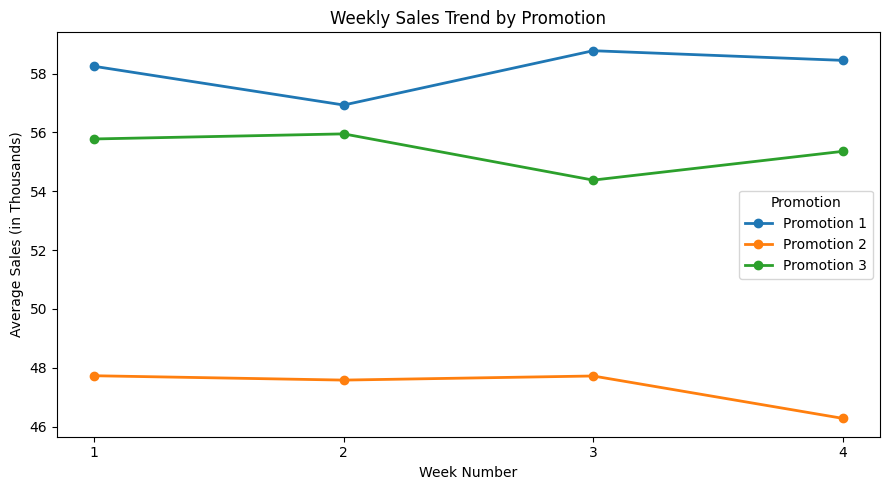

In [ ]:
weekly = df.groupby(['week', 'Promotion'])['SalesInThousands'].mean().reset_index()
# groups by both week AND promotion simultaneously
# .reset_index() converts the grouped result back to a flat table so we can loop through it

plt.figure(figsize=(9, 5))
for promo in [1, 2, 3]:                              # loops once per promotion
    subset = weekly[weekly['Promotion'] == promo]    # filters only rows for that promotion
    plt.plot(subset['week'],                         # x-axis = week number
             subset['SalesInThousands'],             # y-axis = average sales
             marker='o',                             # dot at each data point
             linewidth=2,
             label=f'Promotion {promo}')             # legend label

plt.title('Weekly Sales Trend by Promotion')
plt.xlabel('Week Number')
plt.ylabel('Average Sales (in Thousands)')
plt.xticks([1, 2, 3, 4])   # forces x-axis to show only whole week numbers
plt.legend(title='Promotion')
plt.tight_layout()
plt.show()

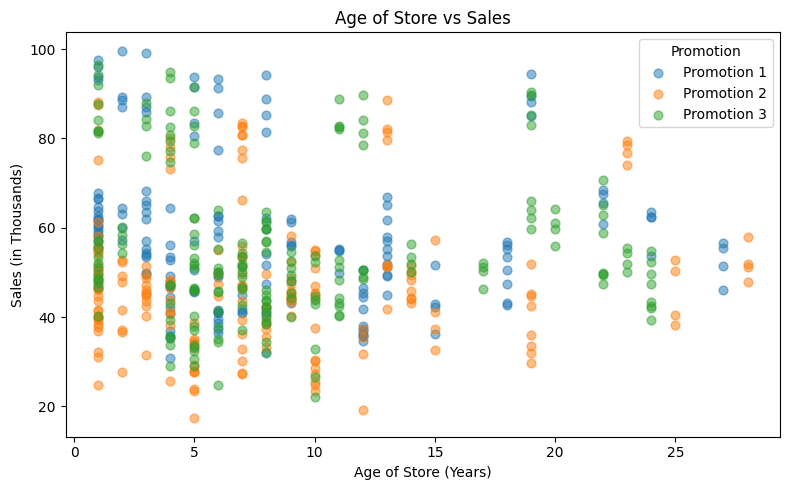

In [ ]:
plt.figure(figsize=(8, 5))
for promo in [1, 2, 3]:
    subset = df[df['Promotion'] == promo]        # filters rows for that promotion
    plt.scatter(subset['AgeOfStore'],            # x-axis = store age in years
                subset['SalesInThousands'],      # y-axis = sales
                alpha=0.5,                       # transparency so overlapping dots are visible
                label=f'Promotion {promo}',
                s=40)                            # dot size

plt.title('Age of Store vs Sales')
plt.xlabel('Age of Store (Years)')
plt.ylabel('Sales (in Thousands)')
plt.legend(title='Promotion')
plt.tight_layout()
plt.show()

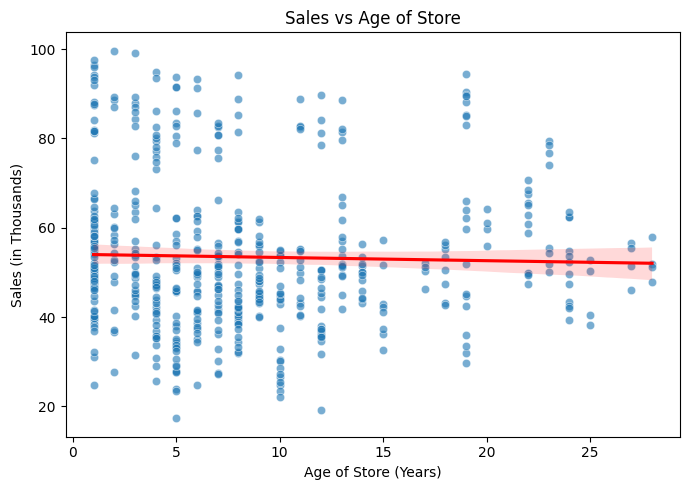

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create figure size
plt.figure(figsize=(7,5))

# Scatter plot: each point = one store observation
sns.scatterplot(x='AgeOfStore',
                y='SalesInThousands',
                data=df,
                alpha=0.6)  # transparency so overlapping points are visible

# Add trend line (regression line)
sns.regplot(x='AgeOfStore',
            y='SalesInThousands',
            data=df,
            scatter=False,   # we already plotted scatter above
            color='red')     # trend line color

# Titles and labels
plt.title('Sales vs Age of Store')
plt.xlabel('Age of Store (Years)')
plt.ylabel('Sales (in Thousands)')

plt.tight_layout()
plt.show()

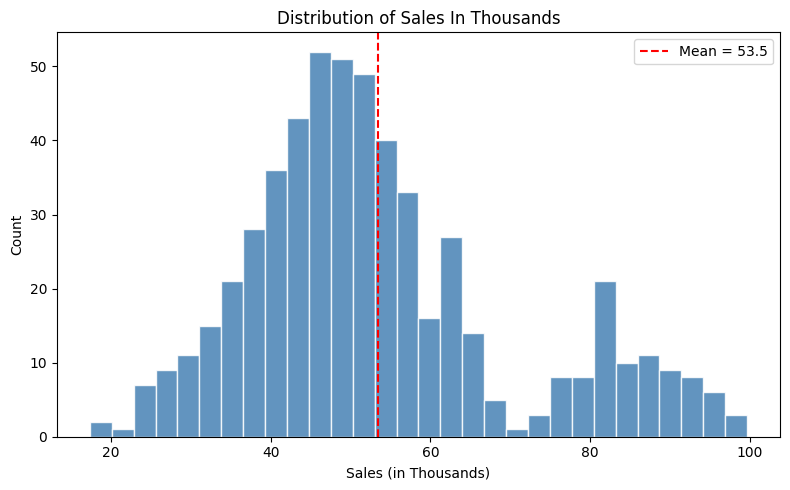

In [ ]:
plt.figure(figsize=(8, 5))          # creates a blank canvas, 8 inches wide and 5 inches tall
plt.hist(df['SalesInThousands'],    # tells it which data to use
         bins=30,                   # splits the data into 30 buckets (more bins = more detail)
         color='steelblue',         # bar color
         edgecolor='white',         # thin white line between bars for clarity
         alpha=0.85)                # slight transparency (1.0 = fully solid, 0 = invisible)
plt.axvline(df['SalesInThousands'].mean(),   # draws a vertical line at the mean sales value
            color='red',
            linestyle='--',
            label=f"Mean = {df['SalesInThousands'].mean():.1f}")   # adds a label showing the mean value
plt.title('Distribution of Sales In Thousands')   # chart title
plt.xlabel('Sales (in Thousands)')                # x-axis label
plt.ylabel('Count')                               # y-axis label
plt.legend()                                      # shows the legend (the red line label)
plt.tight_layout()                                # adjusts spacing so nothing gets cut off
plt.show()                                        # displays the chart

/tmp/ipykernel_10038/3784616812.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Promotion',            # x-axis groups = promotion numbers


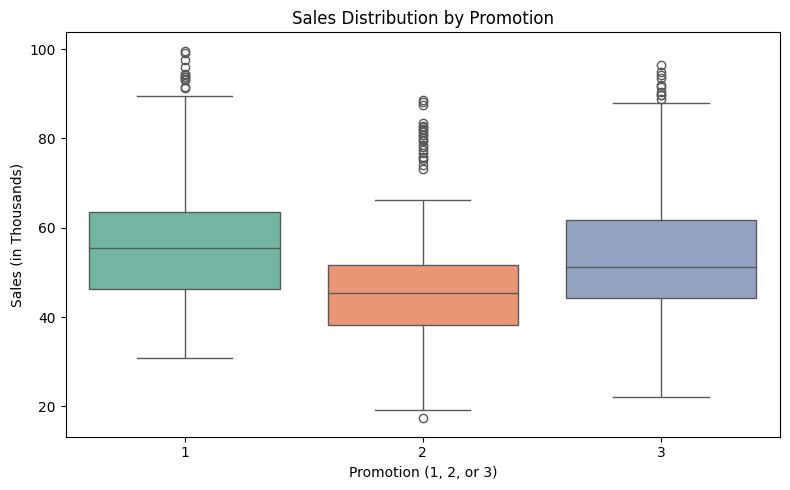

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Promotion',            # x-axis groups = promotion numbers
            y='SalesInThousands',     # y-axis = sales values
            data=df,                  # data source
            palette='Set2')           # color theme
# the box shows the middle 50% of sales values
# the line inside the box = median sales
# the whiskers extend to the min and max (within range)
# dots outside whiskers = outliers (unusually high or low values)
plt.title('Sales Distribution by Promotion')
plt.xlabel('Promotion (1, 2, or 3)')
plt.ylabel('Sales (in Thousands)')
plt.tight_layout()
plt.show()

/tmp/ipykernel_10038/4235813751.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='MarketSize',


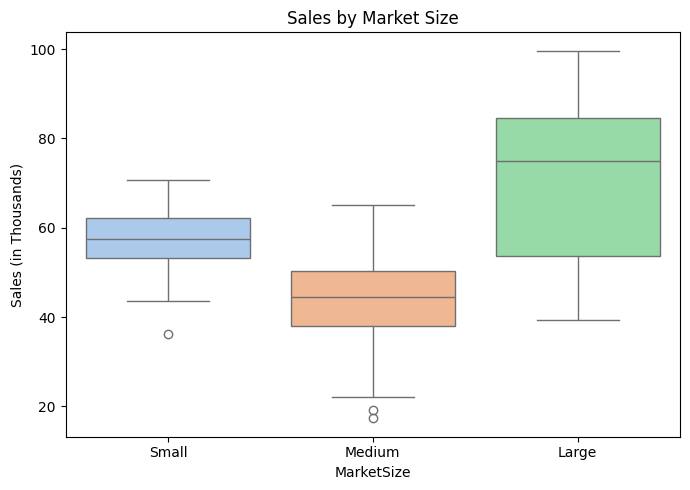

In [ ]:
plt.figure(figsize=(7, 5))
sns.boxplot(x='MarketSize',
            y='SalesInThousands',
            data=df,
            order=['Small', 'Medium', 'Large'],   # forces left-to-right order
            palette='pastel')
plt.title('Sales by Market Size')
plt.ylabel('Sales (in Thousands)')
plt.tight_layout()
plt.show()

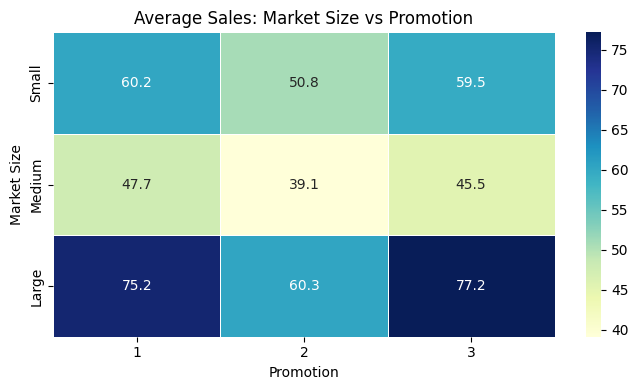

In [ ]:
pivot = df.groupby(['MarketSize', 'Promotion'])['SalesInThousands'].mean().unstack()
# .unstack() reshapes the grouped result into a grid (rows = MarketSize, columns = Promotion)
# this is the format heatmap needs

pivot = pivot.reindex(['Small', 'Medium', 'Large'])   # orders rows top to bottom

plt.figure(figsize=(7, 4))
sns.heatmap(pivot,
            annot=True,       # writes the actual number inside each cell
            fmt=".1f",        # 1 decimal place
            cmap='YlGnBu',    # color scheme: yellow = low, blue = high
            linewidths=0.5)   # thin lines between cells
plt.title('Average Sales: Market Size vs Promotion')
plt.xlabel('Promotion')
plt.ylabel('Market Size')
plt.tight_layout()
plt.show()

In [ ]:
print("ANOVA TEST")
print("Do promotions affect sales?")
print("If p-value < 0.05 → reject the null hypothesis → promotions have a statistically significant effect on sales.")
print("If p-value ≥ 0.05 → fail to reject the null hypothesis → no significant difference between promotions.\n\n")
group1 = df[df['Promotion'] == 1]['SalesInThousands']   # all sales rows where promotion = 1
group2 = df[df['Promotion'] == 2]['SalesInThousands']   # same for promotion 2
group3 = df[df['Promotion'] == 3]['SalesInThousands']   # same for promotion 3

f_stat, p_value = stats.f_oneway(group1, group2, group3)
# f_oneway runs a one-way ANOVA test across the 3 groups
# f_stat = how large the difference is relative to the variation within groups
# p_value = probability that this difference happened by random chance

print(f"F-statistic : {f_stat:.4f}")
print(f"p-value     : {p_value:.6f}")

if p_value < 0.05:
    print("Result: The promotions perform DIFFERENTLY. The difference is statistically significant.")
    # p < 0.05 means less than 5% chance this is random -- the difference is real
else:
    print("Result: No significant difference found between promotions.")

ANOVA TEST
Do promotions affect sales?
If p-value < 0.05 → reject the null hypothesis → promotions have a statistically significant effect on sales.
If p-value ≥ 0.05 → fail to reject the null hypothesis → no significant difference between promotions.


F-statistic : 21.9535
p-value     : 0.000000
Result: The promotions perform DIFFERENTLY. The difference is statistically significant.


In [ ]:
print("H0: u1 = u2 (means are the same)")
print("If p-value < 0.05 → Reject H0 (means are significantly different)")
print("If p-value ≥ 0.05 → Fail to reject H0 (no significant difference detected)\n")
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(endog=df['SalesInThousands'],   # endog = the values being compared
                           groups=df['Promotion'],          # groups = which group each row belongs to
                           alpha=0.05)                      # alpha = significance threshold (5%)
# Tukey HSD compares every possible pair: (1 vs 2), (1 vs 3), (2 vs 3)
# reject=True  means those two promotions are genuinely different
# reject=False means those two are not significantly different from each other

print(tukey)

H0: u1 = u2 (means are the same)
If p-value < 0.05 → Reject H0 (means are significantly different)
If p-value ≥ 0.05 → Fail to reject H0 (no significant difference detected)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     1      2 -10.7696    0.0 -14.7738 -6.7654   True
     1      3  -2.7345 0.2444  -6.7388  1.2697  False
     2      3   8.0351    0.0   4.1208 11.9493   True
-----------------------------------------------------


In [ ]:
from sklearn.model_selection import train_test_split

# -------------------------------------------------------
# STEP 1: COPY DATA
# -------------------------------------------------------
df_model = df.copy()

# -------------------------------------------------------
# STEP 2: DUMMIES + BASELINE (ONLY DONE ON TRAINING PIPELINE SETUP)
# -------------------------------------------------------
df_model = pd.get_dummies(df_model, columns=['MarketSize'], drop_first=True)

df_model['Promotion'] = df_model['Promotion'].astype(str)
df_model = pd.get_dummies(df_model, columns=['Promotion'], drop_first=True)

# -------------------------------------------------------
# STEP 3: DEFINE X AND y
# -------------------------------------------------------
X = df_model.drop(columns=['SalesInThousands', 'MarketID', 'LocationID'])
y = df_model['SalesInThousands']

X = X.astype(float)

# -------------------------------------------------------
# STEP 4: SPLIT DATA (80% TRAIN, 20% TEST)
# -------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=99
)

# -------------------------------------------------------
# STEP 5: ADD CONSTANT (INTERCEPT)
# -------------------------------------------------------
X_train_ols = sm.add_constant(X_train)   # using X_train_ols for OLS

# -------------------------------------------------------
# STEP 6: TRAIN OLS MODEL
# -------------------------------------------------------
model = sm.OLS(y_train, X_train_ols).fit()
train_cols = model.model.exog_names

print("\n--- TRAINING RESULTS ---")
print(model.summary())


--- TRAINING RESULTS ---
                            OLS Regression Results                            
Dep. Variable:       SalesInThousands   R-squared:                       0.571
Model:                            OLS   Adj. R-squared:                  0.565
Method:                 Least Squares   F-statistic:                     95.46
Date:                Mon, 20 Apr 2026   Prob (F-statistic):           5.83e-76
Time:                        12:32:55   Log-Likelihood:                -1661.6
No. Observations:                 438   AIC:                             3337.
Df Residuals:                     431   BIC:                             3366.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const       

=== OLS: MARGINAL EFFECTS ===
Baseline: MarketSize = Large, Promotion = 1

                   Marginal_Effect  Std_Error  p_value  CI_Lower  CI_Upper
AgeOfStore                  0.1509     0.0806   0.0617   -0.0074    0.3092
week                        0.0269     0.4594   0.9533   -0.8760    0.9299
MarketSize_Medium         -25.9281     1.1721   0.0000  -28.2318  -23.6244
MarketSize_Small          -14.2742     1.8586   0.0000  -17.9272  -10.6212
Promotion_2               -11.3347     1.2965   0.0000  -13.8829   -8.7864
Promotion_3                -1.3166     1.2882   0.3073   -3.8486    1.2153

HOW TO READ:
  Numerical  (AgeOfStore, week) → change in SalesInThousands per +1 unit
  Nominal    (MarketSize, Promo) → change in SalesInThousands vs baseline


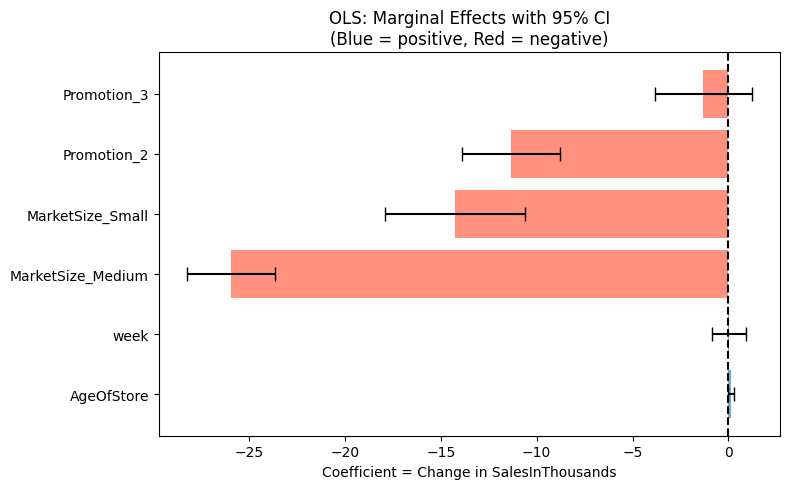

In [ ]:
# ============================================================
# OLS — MARGINAL EFFECTS
# In OLS, coefficients ARE the marginal effects directly.
# Baseline: MarketSize = Large, Promotion = 1
# ============================================================

coef_df = pd.DataFrame({
    'Marginal_Effect' : model.params,
    'Std_Error'       : model.bse,
    'p_value'         : model.pvalues,
    'CI_Lower'        : model.conf_int()[0],
    'CI_Upper'        : model.conf_int()[1]
}).drop('const')   # drop intercept row, not needed for interpretation

print("=== OLS: MARGINAL EFFECTS ===")
print("Baseline: MarketSize = Large, Promotion = 1")
print()
print(coef_df.round(4))
print()
print("HOW TO READ:")
print("  Numerical  (AgeOfStore, week) → change in SalesInThousands per +1 unit")
print("  Nominal    (MarketSize, Promo) → change in SalesInThousands vs baseline")

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 5))
coefs     = coef_df['Marginal_Effect'].values
lower_err = coefs - coef_df['CI_Lower'].values
upper_err = coef_df['CI_Upper'].values - coefs
colors    = ['steelblue' if c > 0 else 'tomato' for c in coefs]

ax.barh(coef_df.index.tolist(), coefs,
        xerr=[lower_err, upper_err],
        color=colors, alpha=0.7, capsize=5)
ax.axvline(0, color='black', linestyle='--', linewidth=1.5)
ax.set_xlabel('Coefficient = Change in SalesInThousands')
ax.set_title('OLS: Marginal Effects with 95% CI\n(Blue = positive, Red = negative)')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

# -------------------------------------------------------
# STEP 1: ADD CONSTANT TO TEST DATA (MUST MATCH TRAIN)
# -------------------------------------------------------
X_test_ols = sm.add_constant(X_test)

# -------------------------------------------------------
# STEP 2: PREDICT USING TRAINED MODEL
# -------------------------------------------------------
y_pred = model.predict(X_test_ols)

# -------------------------------------------------------
# STEP 3: EVALUATE PERFORMANCE
# -------------------------------------------------------
mse_ols = mean_squared_error(y_test, y_pred)
rmse_ols = np.sqrt(mse_ols)
r2_ols = r2_score(y_test, y_pred)

print("\n--- OLS TEST RESULTS ---")
print(f"Mean Squared Error OLS: {mse_ols:.2f}")
print(f"Root Mean Squared Error: {rmse_ols:.2f}")
print(f"R-squared OLS: {r2_ols:.2f}")




--- OLS TEST RESULTS ---
Mean Squared Error OLS: 126.92
Root Mean Squared Error: 11.27
R-squared OLS: 0.61


In [ ]:
# -------------------------------------------------------
# STEP 1: IMPORT LIBRARIES
# -------------------------------------------------------
from sklearn.ensemble import RandomForestRegressor


# -------------------------------------------------------
# STEP 2: CREATE MODEL
# -------------------------------------------------------
rf_model = RandomForestRegressor(
    n_estimators=150,      # number of trees in the forest
    random_state=60       # makes results reproducible
)

# -------------------------------------------------------
# STEP 3: TRAIN MODEL (ONLY ON TRAIN DATA)
# -------------------------------------------------------
rf_model.fit(X_train, y_train)

# -------------------------------------------------------
# STEP 4: PREDICT ON TEST DATA
# -------------------------------------------------------
y_pred_rf = rf_model.predict(X_test)

# -------------------------------------------------------
# STEP 5: EVALUATE PERFORMANCE
# -------------------------------------------------------
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("\n--- RANDOM FOREST TEST RESULTS ---")
print(f"Mean Squared Error: {mse_rf:.2f}")
print(f"Root Mean Squared Error: {rmse_rf:.2f}")
print(f"R-squared: {r2_rf:.2f}")


--- RANDOM FOREST TEST RESULTS ---
Mean Squared Error: 133.48
Root Mean Squared Error: 11.55
R-squared: 0.59


=== RANDOM FOREST: Feature Importances (predicting SalesInThousands) ===
MarketSize_Medium    0.4738
AgeOfStore           0.2462
Promotion_2          0.1037
week                 0.0875
MarketSize_Small     0.0650
Promotion_3          0.0238
dtype: float64

HOW TO READ:
  Higher value = that variable explains more of the variation in Sales
  All values add up to 1.0 (100%)


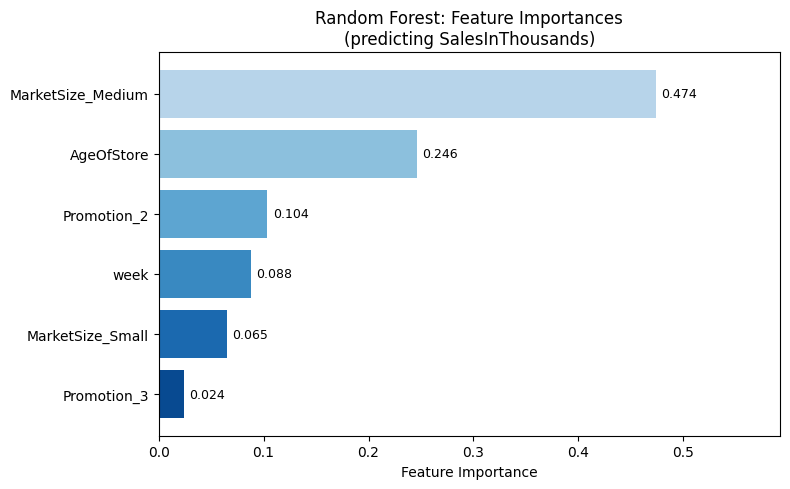

In [ ]:
# ============================================================
# RANDOM FOREST — FEATURE IMPORTANCES
# Shows which variables matter most in predicting Sales
# ============================================================

fi_reg = pd.Series(rf_model.feature_importances_,
                   index=X_train.columns).sort_values(ascending=False)

print("=== RANDOM FOREST: Feature Importances (predicting SalesInThousands) ===")
print(fi_reg.round(4))
print()
print("HOW TO READ:")
print("  Higher value = that variable explains more of the variation in Sales")
print("  All values add up to 1.0 (100%)")

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 5))
colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(fi_reg)))[::-1]
ax.barh(fi_reg.index[::-1], fi_reg.values[::-1], color=colors)
ax.set_xlabel('Feature Importance')
ax.set_title('Random Forest: Feature Importances\n(predicting SalesInThousands)')
ax.set_xlim(0, fi_reg.max() * 1.25)
for i, v in enumerate(fi_reg.values[::-1]):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

Median sales threshold: 50.2
HighSales
0    275
1    273
Name: count, dtype: int64
Confusion Matrix:
[[48 12]
 [ 4 46]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.80      0.86        60
           1       0.79      0.92      0.85        50

    accuracy                           0.85       110
   macro avg       0.86      0.86      0.85       110
weighted avg       0.86      0.85      0.85       110



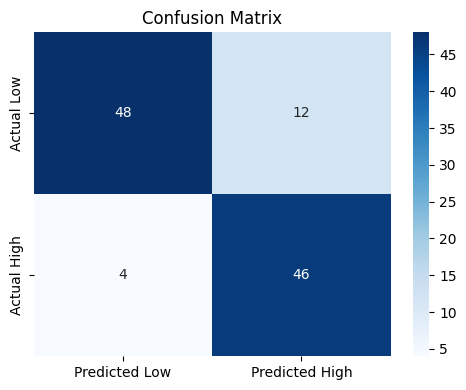

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# --- Create binary target column ---
median_sales = df['SalesInThousands'].median()   # finds the middle value of all sales
df['HighSales'] = (df['SalesInThousands'] > median_sales).astype(int)
# compares every sales value to the median
# True (above median) becomes 1 = High Sales
# False (below median) becomes 0 = Low Sales
# .astype(int) converts True/False to 1/0

print(f"Median sales threshold: {median_sales}")
print(df['HighSales'].value_counts())   # shows how many 1s and 0s we created

# --- Prepare features ---
df_logit = df.copy()
df_logit = pd.get_dummies(df_logit, columns=['MarketSize'], drop_first=True)   # same as Step 13
df_logit['Promotion'] = df_logit['Promotion'].astype(str)
df_logit = pd.get_dummies(df_logit, columns=['Promotion'], drop_first=True)

X_logit = df_logit.drop(columns=['SalesInThousands', 'HighSales', 'MarketID', 'LocationID'])
# removes the target columns and ID columns from features
X_logit = X_logit.astype(float)          # converts all to float

y_logit = df_logit['HighSales']           # target = the binary column we created (0 or 1)

# --- Split into training and testing ---
X_train, X_test, y_train, y_test = train_test_split(
    X_logit, y_logit, test_size=0.2, random_state=99)
# test_size=0.2 means 80% of rows go to training, 20% go to testing
# random_state=42 fixes the random split so you get the same result every time you run it

# --- Train the model ---
log_reg = LogisticRegression(max_iter=1000)   # creactes the model; max_iter avoids convergence warnings
log_reg.fit(X_train, y_train)                 # trains the model using the training data

# --- Evaluate ---
y_pred = log_reg.predict(X_test)   # uses the trained model to predict on unseen test data

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
# a 2x2 grid showing:
# top-left     = correctly predicted Low Sales (True Negative)
# top-right    = Low Sales wrongly predicted as High (False Positive)
# bottom-left  = High Sales wrongly predicted as Low (False Negative)
# bottom-right = correctly predicted High Sales (True Positive)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))
# Precision = of all stores predicted as High, how many actually were High
# Recall    = of all actual High stores, how many did we correctly catch
# F1-score  = balance between Precision and Recall (higher = better)
# Accuracy  = total correct predictions out of all predictions

# --- Confusion matrix chart ---
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True,          # writes the count number inside each cell
            fmt='d',             # integer format (no decimals)
            cmap='Blues',        # color scale
            xticklabels=['Predicted Low', 'Predicted High'],
            yticklabels=['Actual Low', 'Actual High'])
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

=== LOGIT MODEL SUMMARY (statsmodels) ===
                           Logit Regression Results                           
Dep. Variable:              HighSales   No. Observations:                  548
Model:                          Logit   Df Residuals:                      541
Method:                           MLE   Df Model:                            6
Date:                Mon, 20 Apr 2026   Pseudo R-squ.:                  0.3445
Time:                        12:32:59   Log-Likelihood:                -248.97
converged:                       True   LL-Null:                       -379.84
Covariance Type:            nonrobust   LLR p-value:                 1.269e-53
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 2.7915      0.430      6.487      0.000       1.948       3.635
AgeOfStore            0.0353      0.017      2.068      0.039       

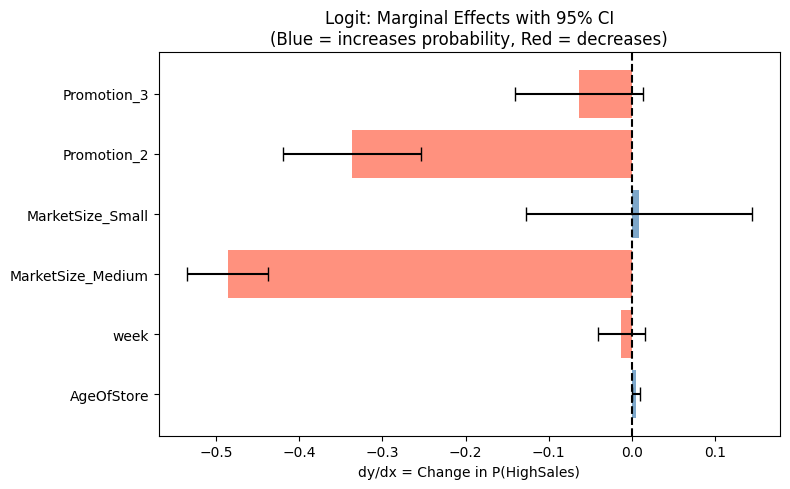


=== LOGIT: ODDS RATIOS ===
Baseline: MarketSize = Large, Promotion = 1

                   Odds_Ratio  OR_Lower_CI  OR_Upper_CI
AgeOfStore             1.0359       1.0018       1.0711
week                   0.9198       0.7572       1.1174
MarketSize_Medium      0.0378       0.0207       0.0689
MarketSize_Small       1.0601       0.4250       2.6443
Promotion_2            0.1035       0.0547       0.1958
Promotion_3            0.6510       0.3863       1.0970

HOW TO READ:
  OR > 1  → variable INCREASES the odds of HighSales
  OR < 1  → variable DECREASES the odds of HighSales
  OR = 1  → no effect at all


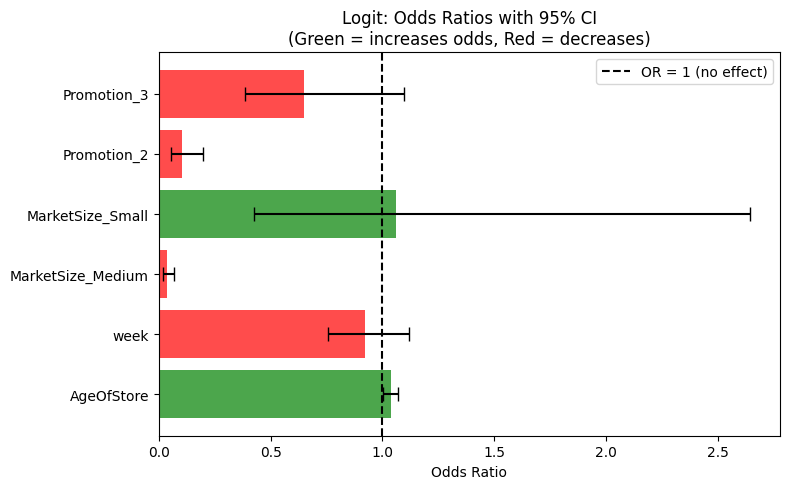

In [ ]:
# ============================================================
# LOGIT — MARGINAL EFFECTS + ODDS RATIOS (using statsmodels)
# Re-fitting on same X_train / y_train from Cell 20 above
# Baseline: MarketSize = Large, Promotion = 1
# ============================================================

# --- Re-fit using statsmodels (sklearn can't give marginal effects) ---
X_train_sm = sm.add_constant(X_train.astype(float))
X_full_sm  = sm.add_constant(X_logit.astype(float))  # full data for overall marginal effects

logit_sm     = sm.Logit(y_logit, X_full_sm).fit(disp=0)
# disp=0 suppresses the iteration output

print("=== LOGIT MODEL SUMMARY (statsmodels) ===")
print(logit_sm.summary())

# ---------------------------
# MARGINAL EFFECTS
# ---------------------------
mfx    = logit_sm.get_margeff()
mfx_df = mfx.summary_frame()
mfx_df.columns = ['dy/dx', 'Std_Err', 'z', 'p_value', 'CI_Lower', 'CI_Upper']

print("\n=== LOGIT: MARGINAL EFFECTS ===")
print("Baseline: MarketSize = Large, Promotion = 1")
print()
print(mfx_df.round(4))
print()
print("HOW TO READ:")
print("  Numerical  (AgeOfStore, week) → dy/dx = change in P(HighSales) per +1 unit")
print("  Nominal    (MarketSize, Promo) → dy/dx = change in P(HighSales) vs baseline")

# --- Plot Marginal Effects ---
fig, ax = plt.subplots(figsize=(8, 5))
dydx      = mfx_df['dy/dx'].values
lower_err = dydx - mfx_df['CI_Lower'].values
upper_err = mfx_df['CI_Upper'].values - dydx
colors    = ['steelblue' if d > 0 else 'tomato' for d in dydx]

ax.barh(mfx_df.index.tolist(), dydx,
        xerr=[lower_err, upper_err],
        color=colors, alpha=0.7, capsize=5)
ax.axvline(0, color='black', linestyle='--', linewidth=1.5)
ax.set_xlabel('dy/dx = Change in P(HighSales)')
ax.set_title('Logit: Marginal Effects with 95% CI\n(Blue = increases probability, Red = decreases)')
plt.tight_layout()
plt.show()

# ---------------------------
# ODDS RATIOS
# ---------------------------
odds_ratios = np.exp(logit_sm.params)
or_ci       = np.exp(logit_sm.conf_int())
or_ci.columns = ['OR_Lower_CI', 'OR_Upper_CI']
or_df = pd.concat([odds_ratios.rename('Odds_Ratio'), or_ci], axis=1).drop('const')

print("\n=== LOGIT: ODDS RATIOS ===")
print("Baseline: MarketSize = Large, Promotion = 1")
print()
print(or_df.round(4))
print()
print("HOW TO READ:")
print("  OR > 1  → variable INCREASES the odds of HighSales")
print("  OR < 1  → variable DECREASES the odds of HighSales")
print("  OR = 1  → no effect at all")

# --- Plot Odds Ratios ---
fig, ax = plt.subplots(figsize=(8, 5))
ors       = or_df['Odds_Ratio'].values
lower_err = ors - or_df['OR_Lower_CI'].values
upper_err = or_df['OR_Upper_CI'].values - ors
colors    = ['green' if o > 1 else 'red' for o in ors]

ax.barh(or_df.index.tolist(), ors,
        xerr=[lower_err, upper_err],
        color=colors, alpha=0.7, capsize=5)
ax.axvline(1, color='black', linestyle='--', linewidth=1.5, label='OR = 1 (no effect)')
ax.set_xlabel('Odds Ratio')
ax.set_title('Logit: Odds Ratios with 95% CI\n(Green = increases odds, Red = decreases)')
ax.legend()
plt.tight_layout()
plt.show()

Median threshold : 50.2K
High Sales : 273
Low Sales  : 275

Split percentage:
HighSales_probit
0    50.0
1    50.0
Name: proportion, dtype: float64
Optimization terminated successfully.
         Current function value: 0.469988
         Iterations 6

--- PROBIT MODEL SUMMARY (MEDIAN THRESHOLD) ---
                          Probit Regression Results                           
Dep. Variable:       HighSales_probit   No. Observations:                  438
Model:                         Probit   Df Residuals:                      431
Method:                           MLE   Df Model:                            6
Date:                Mon, 20 Apr 2026   Pseudo R-squ.:                  0.3211
Time:                        12:33:00   Log-Likelihood:                -205.85
converged:                       True   LL-Null:                       -303.23
Covariance Type:            nonrobust   LLR p-value:                 2.488e-39
                        coef    std err          z      P>|z|      [0

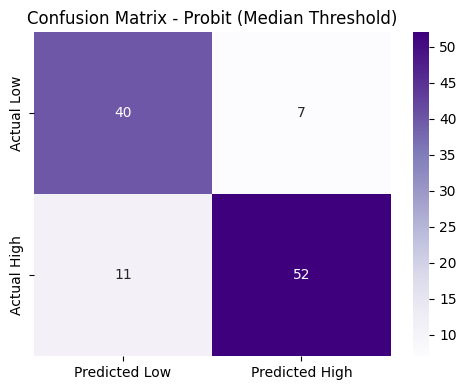

In [ ]:
# -------------------------------------------------------
# PROBIT V1 - MEDIAN THRESHOLD (50/50 SPLIT)
# -------------------------------------------------------

# --- Threshold ---
median_sales_pb = df['SalesInThousands'].median()
# renamed to median_sales_pb so it does not clash with the logistic version

df['HighSales_probit'] = (df['SalesInThousands'] > median_sales_pb).astype(int)
# renamed to HighSales_probit

print(f"Median threshold : {median_sales_pb}K")
print(f"High Sales : {df['HighSales_probit'].sum()}")
print(f"Low Sales  : {(df['HighSales_probit'] == 0).sum()}")
print(f"\nSplit percentage:")
print(df['HighSales_probit'].value_counts(normalize=True).round(2) * 100)

# --- Prepare features ---
df_probit = df.copy()   # renamed to df_probit
df_probit = pd.get_dummies(df_probit, columns=['MarketSize'], drop_first=True)
df_probit['Promotion'] = df_probit['Promotion'].astype(str)
df_probit = pd.get_dummies(df_probit, columns=['Promotion'], drop_first=True)

X_probit = df_probit.drop(columns=['SalesInThousands', 'HighSales',
                                    'HighSales_probit', 'MarketID', 'LocationID'])
# drops all target columns so none of them leak into features
X_probit = X_probit.astype(float)

y_probit = df_probit['HighSales_probit']

# --- Split ---
X_train_pb, X_test_pb, y_train_pb, y_test_pb = train_test_split(
    X_probit, y_probit, test_size=0.2, random_state=42)
# all variables use _pb suffix (short for probit)

# --- Add constant (statsmodels needs this manually) ---
X_train_pb_const = sm.add_constant(X_train_pb)
X_test_pb_const  = sm.add_constant(X_test_pb)
# statsmodels does not add the intercept automatically unlike sklearn
# so we do it manually for both train and test

# --- Train Probit model ---
probit_model = sm.Probit(y_train_pb, X_train_pb_const)
# sm.Probit takes (target, features) -- note: opposite order to sklearn
probit_result = probit_model.fit()
# .fit() trains the model and stores full stats in probit_result

print("\n--- PROBIT MODEL SUMMARY (MEDIAN THRESHOLD) ---")
print(probit_result.summary())
# summary shows coefficients, p-values, and model fit stats
# coef > 0 means that variable increases probability of High Sales
# coef < 0 means it decreases the probability

# --- Predict on test data ---
y_pred_pb_prob = probit_result.predict(X_test_pb_const)
# probit gives probabilities (0.0 to 1.0), not direct 0/1 labels
# so we convert: anything above 0.5 = High Sales (1), below = Low Sales (0)

y_pred_pb = (y_pred_pb_prob > 0.5).astype(int)
# renamed to y_pred_pb

print("\nConfusion Matrix (Probit - Median Threshold):")
print(confusion_matrix(y_test_pb, y_pred_pb))

print("\nClassification Report (Probit - Median Threshold):")
print(classification_report(y_test_pb, y_pred_pb))

# --- Confusion matrix chart ---
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test_pb, y_pred_pb),
            annot=True,
            fmt='d',
            cmap='Purples',   # different color from logistic versions
            xticklabels=['Predicted Low', 'Predicted High'],
            yticklabels=['Actual Low', 'Actual High'])
plt.title('Confusion Matrix - Probit (Median Threshold)')
plt.tight_layout()
plt.show()

=== PROBIT V1 (MEDIAN): MARGINAL EFFECTS ===
Baseline: MarketSize = Large, Promotion = 1

                    dy/dx  Std_Err        z  p_value  CI_Lower  CI_Upper
AgeOfStore         0.0051   0.0025   2.0749   0.0380    0.0003    0.0100
week              -0.0120   0.0147  -0.8113   0.4172   -0.0408    0.0169
MarketSize_Medium -0.4824   0.0223 -21.5912   0.0000   -0.5262   -0.4386
MarketSize_Small   0.0149   0.0668   0.2235   0.8231   -0.1160    0.1459
Promotion_2       -0.3187   0.0385  -8.2800   0.0000   -0.3942   -0.2433
Promotion_3       -0.0638   0.0399  -1.5987   0.1099   -0.1421    0.0144

HOW TO READ:
  Numerical  (AgeOfStore, week)  → dy/dx = change in P(HighSales) per +1 unit
  Nominal    (MarketSize, Promo) → dy/dx = change in P(HighSales) vs baseline


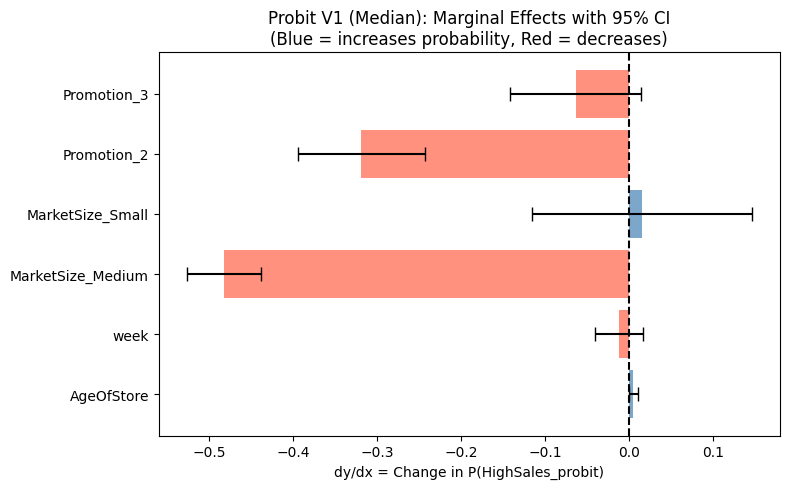

In [ ]:
# ============================================================
# PROBIT V1 (MEDIAN) — MARGINAL EFFECTS
# probit_result and X_probit already exist from the cell above
# Baseline: MarketSize = Large, Promotion = 1
# NOTE: Odds Ratios do NOT apply to Probit (uses normal curve,
#       not logistic curve). Marginal effects are the correct output.
# ============================================================

# --- Fit on full data for stable marginal effects ---
X_probit_full_const = sm.add_constant(X_probit.astype(float))
probit_full = sm.Probit(y_probit, X_probit_full_const).fit(disp=0)

# --- Marginal Effects ---
mfx_pb    = probit_full.get_margeff()
mfx_pb_df = mfx_pb.summary_frame()
mfx_pb_df.columns = ['dy/dx', 'Std_Err', 'z', 'p_value', 'CI_Lower', 'CI_Upper']

print("=== PROBIT V1 (MEDIAN): MARGINAL EFFECTS ===")
print("Baseline: MarketSize = Large, Promotion = 1")
print()
print(mfx_pb_df.round(4))
print()
print("HOW TO READ:")
print("  Numerical  (AgeOfStore, week)  → dy/dx = change in P(HighSales) per +1 unit")
print("  Nominal    (MarketSize, Promo) → dy/dx = change in P(HighSales) vs baseline")

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 5))
dydx      = mfx_pb_df['dy/dx'].values
lower_err = dydx - mfx_pb_df['CI_Lower'].values
upper_err = mfx_pb_df['CI_Upper'].values - dydx
colors    = ['steelblue' if d > 0 else 'tomato' for d in dydx]

ax.barh(mfx_pb_df.index.tolist(), dydx,
        xerr=[lower_err, upper_err],
        color=colors, alpha=0.7, capsize=5)
ax.axvline(0, color='black', linestyle='--', linewidth=1.5)
ax.set_xlabel('dy/dx = Change in P(HighSales_probit)')
ax.set_title('Probit V1 (Median): Marginal Effects with 95% CI\n(Blue = increases probability, Red = decreases)')
plt.tight_layout()
plt.show()

In [ ]:
def predict_all():

    # ----------------------------
    # INPUT ONCE FOR ALL MODELS
    # ----------------------------
    MarketSize = input("MarketSize (Small/Medium/Large): ")
    AgeOfStore = int(input("AgeOfStore: "))
    Promotion  = input("Promotion (1/2/3): ")
    week       = int(input("week: "))

    # ----------------------------
    # BUILD BASE DATAFRAME
    # ----------------------------
    new_data = pd.DataFrame([{
        "MarketSize": MarketSize,
        "AgeOfStore": AgeOfStore,
        "Promotion":  Promotion,
        "week":       week
    }])

    # ----------------------------
    # ONE-HOT ENCODING
    # ----------------------------
    for val in ["Medium", "Small"]:        # baseline = Large
        new_data[f"MarketSize_{val}"] = int(MarketSize == val)

    for val in ["2", "3"]:                 # baseline = Promotion 1
        new_data[f"Promotion_{val}"] = int(Promotion == val)

    new_data = new_data.drop(columns=["MarketSize", "Promotion"])

    # ----------------------------
    # OLS INPUT
    # ----------------------------
    ols_input = new_data.reindex(columns=X.columns, fill_value=0).astype(float)
    ols_input_const = sm.add_constant(ols_input.copy(), has_constant='add')
    ols_input_const = ols_input_const.reindex(columns=train_cols, fill_value=0)

    # ----------------------------
    # RANDOM FOREST INPUT
    # ----------------------------
    rf_input = new_data.reindex(columns=X.columns, fill_value=0).astype(float)

    # ----------------------------
    # LOGISTIC INPUT
    # ----------------------------
    logit_input = new_data.reindex(columns=X_logit.columns, fill_value=0).astype(float)

    # ----------------------------
    # PROBIT INPUT
    # ----------------------------
    probit_input       = new_data.reindex(columns=X_logit.columns, fill_value=0).astype(float)
    probit_input_const = sm.add_constant(probit_input.copy(), has_constant='add')
    probit_input_const = probit_input_const.reindex(columns=X_train_pb_const.columns, fill_value=0)

    # ----------------------------
    # RUN ALL 4 MODELS
    # ----------------------------
    ols_pred    = model.predict(ols_input_const.values)[0]
    rf_pred     = rf_model.predict(rf_input)[0]
    logit_prob  = log_reg.predict_proba(logit_input)[0][1]
    logit_label = log_reg.predict(logit_input)[0]
    probit_prob  = probit_result.predict(probit_input_const).values[0]
    probit_label = int(probit_prob > 0.5)

    # ----------------------------
    # OUTPUT
    # ----------------------------
    print("\n============================================")
    print("               RESULTS SUMMARY")
    print("============================================")
    print(f"  MarketSize : {MarketSize}")
    print(f"  AgeOfStore : {AgeOfStore}")
    print(f"  Promotion  : {Promotion}")
    print(f"  Week       : {week}")
    print("============================================")

    print("\n--- REGRESSION (How much will it sell?) ---")
    print(f"\n  OLS:")
    print(f"    Predicted Sales : {ols_pred:.2f}K")
    print(f"    R²              : {r2_ols:.2f}")
    print(f"    RMSE            : {rmse_ols:.2f}")

    print(f"\n  Random Forest:")
    print(f"    Predicted Sales : {rf_pred:.2f}K")
    print(f"    R²              : {r2_rf:.2f}")
    print(f"    RMSE            : {rmse_rf:.2f}")

    print("\n--- CLASSIFICATION (High or Low Sales?) ---")
    print(f"  Threshold used : Median (50.2K)")

    print(f"\n  Logistic Regression:")
    print(f"    Probability of High Sales : {logit_prob * 100:.1f}%")
    print(f"    Prediction                : {'HIGH SALES' if logit_label == 1 else 'LOW SALES'}")

    print(f"\n  Probit:")
    print(f"    Probability of High Sales : {probit_prob * 100:.1f}%")
    print(f"    Prediction                : {'HIGH SALES' if probit_label == 1 else 'LOW SALES'}")

    print("\n============================================")

In [ ]:
while True:

    print("\n========================")
    print("PRESS 1 → Predict + Classify")
    print("PRESS 0 → Exit")
    print("========================")

    choice = input("Enter choice: ")

    if choice == "1":
        predict_all()
        break

    elif choice == "0":
        print("Exiting program... Goodbye!")
        break

    else:
        print("Invalid input. Please press 1 or 0.")


PRESS 1 → Predict + Classify
PRESS 0 → Exit
Enter choice: 0
Exiting program... Goodbye!
